# NeuroKit2 Feature Engineering Starter

This notebook demonstrates a small, repeatable pilot for extracting PPG features with NeuroKit2. It samples a few complete five-second windows from one randomly selected source record in each data part; it does not process the full dataset.

For each window, NeuroKit2 cleans PPG and detects pulses. The notebook derives simple pulse and signal-summary features, retains source provenance, and compares the cleaned signal with the raw PPG and synchronized ABP. ABP is used only to create provisional reference labels (window maximum/minimum), never as a model input feature.

These features and the default detector are exploratory, not clinically validated. A failed detection is recorded rather than silently repaired or dropped.

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import neurokit2 as nk
import numpy as np
import pandas as pd

FS = 125
WINDOW_SIZE = 5 * FS
RANDOM_SEED = 2026
RECORDS_PER_PART = 1
WINDOWS_PER_RECORD = 3
PART_FILES = [f"Part_{number}.mat" for number in range(1, 5)]

ROOT = Path.cwd()
if not (ROOT / "data" / "raw").is_dir():
    ROOT = ROOT.parent
RAW_DIR = ROOT / "data" / "raw"
missing_files = [name for name in PART_FILES if not (RAW_DIR / name).is_file()]
if missing_files:
    raise FileNotFoundError(
        f"Missing raw files in {RAW_DIR}: {', '.join(missing_files)}. "
        "See data/README.md for setup instructions."
    )

print(f"NeuroKit2 version: {nk.__version__}")
print(f"Data directory: {RAW_DIR}")
print("If imports are missing, install with: python -m pip install neurokit2 pandas")

NeuroKit2 version: 0.2.13
Data directory: /Users/katherinewu/Desktop/Microsoft-1D-educational-blood-pressure-estimation/data/raw
If imports are missing, install with: python -m pip install neurokit2 pandas


## Load a small reproducible sample

One source record is chosen at random from each storage part using a fixed seed, then up to three complete windows are taken from each selected record. The file parts are only storage divisions; this sampling is for a quick technical pilot, not a representative statistical sample. Each row retains part, record, and window identifiers for later grouped splitting.

In [2]:
rng = np.random.default_rng(RANDOM_SEED)
sample_windows = []
selected_records = {}

for part_number, filename in enumerate(PART_FILES, start=1):
    with h5py.File(RAW_DIR / filename, "r") as source:
        references = source[f"Part_{part_number}"]
        record_indices = rng.choice(
            references.shape[0], size=RECORDS_PER_PART, replace=False
        )
        selected_records[filename] = [int(index) for index in record_indices]

        for record_index in record_indices:
            record = source[references[int(record_index), 0]][()]
            if record.ndim != 2 or record.shape[1] != 3:
                raise ValueError(
                    f"Unexpected shape in {filename}, record {record_index}: {record.shape}"
                )
            window_count = min(record.shape[0] // WINDOW_SIZE, WINDOWS_PER_RECORD)
            windows = record[:window_count * WINDOW_SIZE].reshape(
                window_count, WINDOW_SIZE, 3
            )
            for window_index, window in enumerate(windows):
                ppg = window[:, 0].astype(float, copy=True)
                abp = window[:, 1].astype(float, copy=True)
                sample_windows.append(
                    {
                        "part": filename,
                        "record_index": int(record_index),
                        "window_index": window_index,
                        "ppg": ppg,
                        "abp": abp,
                        "sbp_window_max": float(np.max(abp)),
                        "dbp_window_min": float(np.min(abp)),
                    }
                )

if not sample_windows:
    raise ValueError("No complete windows found in the selected records.")

print(f"Selected source records: {selected_records}")
print(f"Sample windows: {len(sample_windows)}")

Selected source records: {'Part_1.mat': [2555], 'Part_2.mat': [536], 'Part_3.mat': [79], 'Part_4.mat': [1919]}
Sample windows: 10


## Process PPG and create per-window features

`nk.ppg_process` returns cleaned PPG, detected peak markers, an estimated rate series, and a quality series. The feature table below includes simple descriptive features and diagnostic fields. `ppg_zero_fraction`, detection status, and quality summary are quality-control information; decide separately whether any belong in a model. The ABP-derived SBP/DBP columns are targets only.

In [3]:
feature_rows = []
processed_examples = []

for item in sample_windows:
    ppg = item["ppg"]
    row = {
        "part": item["part"],
        "record_index": item["record_index"],
        "window_index": item["window_index"],
        "sbp_window_max_target": item["sbp_window_max"],
        "dbp_window_min_target": item["dbp_window_min"],
        "ppg_zero_count_qc": int(np.count_nonzero(ppg == 0)),
        "ppg_zero_fraction_qc": float(np.mean(ppg == 0)),
        "ppg_raw_range_qc": float(np.ptp(ppg)),
        "ppg_raw_std_qc": float(np.std(ppg)),
        "processing_status": "failed",
        "processing_error": "",
    }
    try:
        if not np.isfinite(ppg).all():
            raise ValueError("PPG contains non-finite values")
        signals, info = nk.ppg_process(ppg, sampling_rate=FS)
        clean = signals["PPG_Clean"].to_numpy(dtype=float)
        peak_mask = signals["PPG_Peaks"].to_numpy(dtype=int) > 0
        peak_indices = np.flatnonzero(peak_mask)
        peak_intervals = np.diff(peak_indices) / FS
        pulse_rates = 60.0 / peak_intervals if len(peak_intervals) else np.array([])
        rate_series = signals["PPG_Rate"].to_numpy(dtype=float)
        quality_series = signals["PPG_Quality"].to_numpy(dtype=float)

        pulse_amplitudes = []
        for previous_peak, current_peak in zip(peak_indices[:-1], peak_indices[1:]):
            segment = clean[previous_peak:current_peak + 1]
            if len(segment):
                pulse_amplitudes.append(float(clean[current_peak] - np.min(segment)))

        row.update(
            {
                "ppg_clean_mean_feature": float(np.mean(clean)),
                "ppg_clean_std_feature": float(np.std(clean)),
                "ppg_clean_range_feature": float(np.ptp(clean)),
                "detected_peak_count_qc": int(len(peak_indices)),
                "median_interpeak_interval_s_feature": float(np.median(peak_intervals)) if len(peak_intervals) else np.nan,
                "median_rate_from_peaks_bpm_feature": float(np.median(pulse_rates)) if len(pulse_rates) else np.nan,
                "median_neurokit_rate_bpm_qc": float(np.nanmedian(rate_series)) if np.isfinite(rate_series).any() else np.nan,
                "median_pulse_amplitude_feature": float(np.median(pulse_amplitudes)) if pulse_amplitudes else np.nan,
                "median_neurokit_quality_qc": float(np.nanmedian(quality_series)) if np.isfinite(quality_series).any() else np.nan,
                "processing_status": "ok",
            }
        )
        processed_examples.append({**item, "clean": clean, "peak_indices": peak_indices})
    except Exception as error:
        row["processing_error"] = f"{type(error).__name__}: {error}"
    feature_rows.append(row)

features = pd.DataFrame(feature_rows)
display(features)
print("Feature extraction status:")
print(features["processing_status"].value_counts(dropna=False))
if features["processing_status"].ne("ok").any():
    display(features.loc[features["processing_status"].ne("ok"), ["part", "record_index", "window_index", "processing_error"]])

,part,record_index,window_index,sbp_window_max_target,dbp_window_min_target,ppg_zero_count_qc,ppg_zero_fraction_qc,ppg_raw_range_qc,ppg_raw_std_qc,processing_status,processing_error,ppg_clean_mean_feature,ppg_clean_std_feature,ppg_clean_range_feature,detected_peak_count_qc,median_interpeak_interval_s_feature,median_rate_from_peaks_bpm_feature,median_neurokit_rate_bpm_qc,median_pulse_amplitude_feature,median_neurokit_quality_qc
0,Part_1.mat,2555,0,150.000244,69.358628,0,0.0,2.395894,0.558658,ok,,-0.003228,0.509823,1.871226,7,0.624,96.153846,96.469653,1.496669,0.991185
1,Part_1.mat,2555,1,145.115834,66.623358,0,0.0,2.137830,0.519144,ok,,0.012124,0.514625,2.046242,7,0.632,94.936709,94.649720,1.432421,0.999449
2,Part_1.mat,2555,2,146.630001,68.919031,0,0.0,2.569892,0.609584,ok,,0.036603,0.564216,2.340343,7,0.640,93.750000,93.750000,1.487758,0.991768
3,Part_2.mat,536,0,105.997462,58.865749,0,0.0,0.634409,0.161615,ok,,0.007647,0.149794,0.543812,6,0.760,78.947368,78.781513,0.415600,0.998104
4,Part_2.mat,536,1,106.193029,59.061316,0,0.0,0.569892,0.154415,ok,,-0.005047,0.152691,0.518303,7,0.768,78.125000,78.836598,0.462413,0.980983
5,Part_2.mat,536,2,105.997462,59.061316,0,0.0,0.558162,0.131948,ok,,-0.005032,0.123718,0.458996,6,0.768,78.125000,77.479339,0.338738,0.997396
6,Part_3.mat,79,0,109.322105,52.803163,0,0.0,0.523949,0.164579,ok,,0.000427,0.161899,0.524861,6,0.896,66.964286,67.902478,0.476733,0.999045
7,Part_3.mat,79,1,109.322105,51.825327,0,0.0,0.705767,0.169485,ok,,-0.002295,0.163317,0.653350,5,0.904,66.376880,66.371681,0.456492,0.996445
8,Part_3.mat,79,2,109.126538,52.020894,0,0.0,0.521017,0.158873,ok,,0.001215,0.154707,0.526690,5,0.884,67.874693,68.027211,0.481686,0.998664
9,Part_4.mat,1919,0,128.487698,64.341633,0,0.0,0.807429,0.171225,ok,,0.000508,0.142244,0.593871,10,0.472,127.118644,127.358491,0.372468,0.978044


Feature extraction status:
processing_status
ok    10
Name: count, dtype: int64


## Visually inspect NeuroKit output

Overlay the cleaned PPG and detected peaks on the raw waveform, and compare with the synchronized ABP. A plausible-looking feature table is not enough: inspect missed or extra peaks and pay special attention to windows containing zeros or unusually low PPG range.

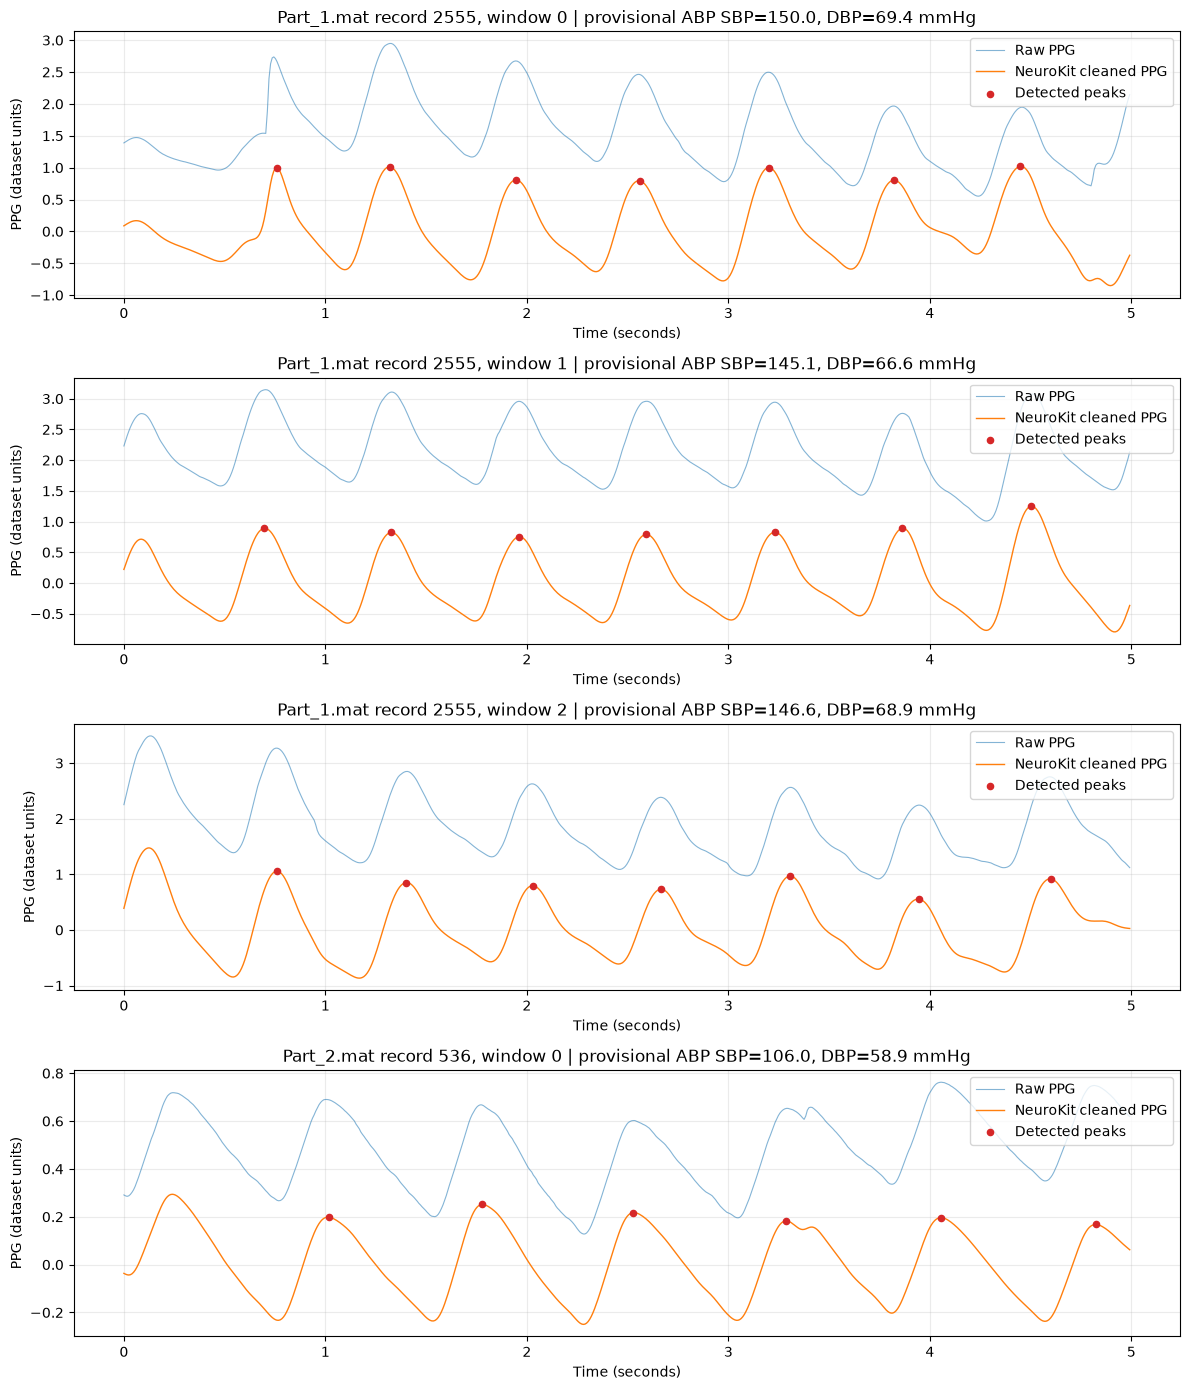

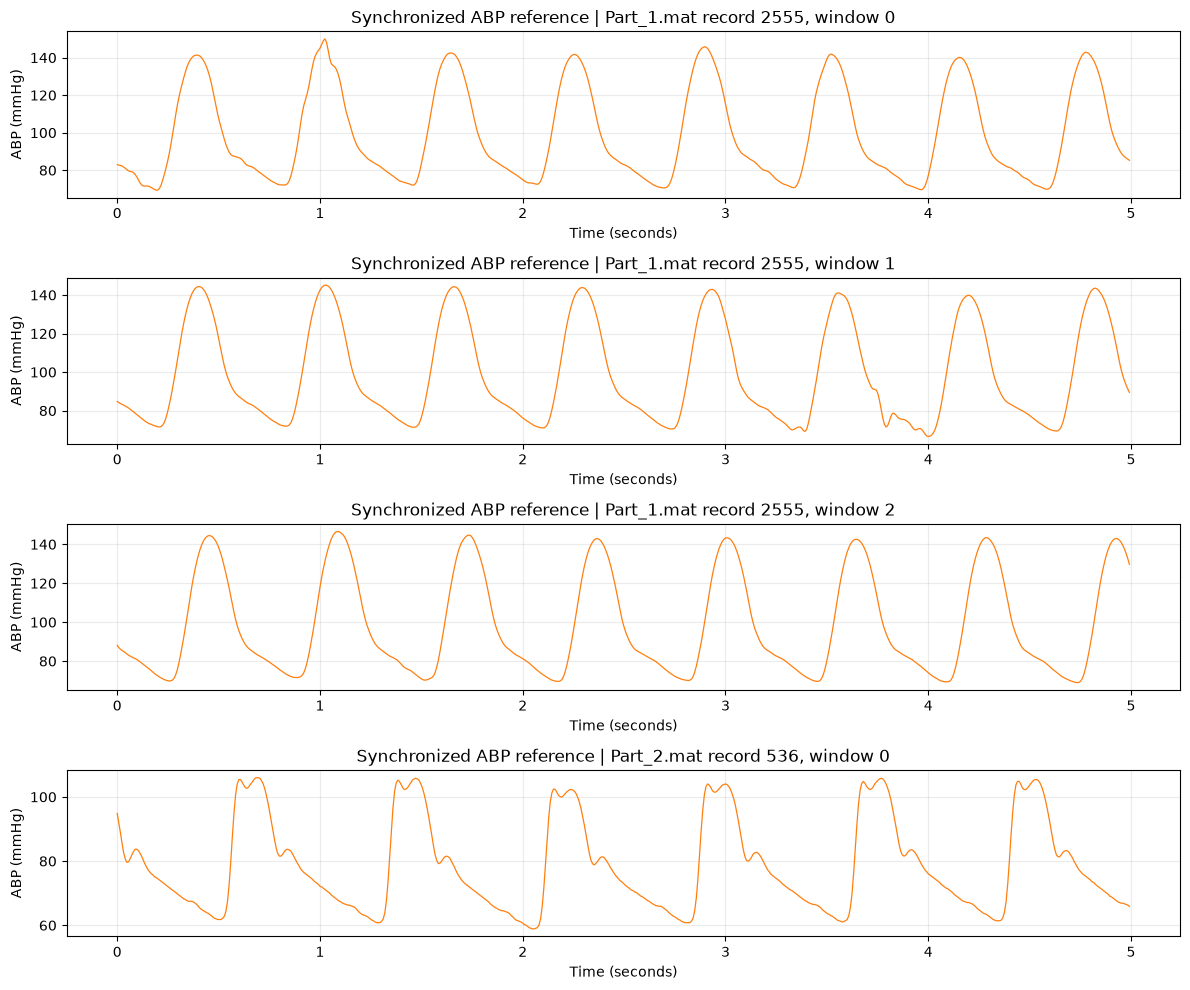

In [4]:
if not processed_examples:
    print("No windows processed successfully; inspect the errors above.")
else:
    examples_to_plot = processed_examples[:min(4, len(processed_examples))]
    fig, axes = plt.subplots(len(examples_to_plot), 1, figsize=(12, 3.5 * len(examples_to_plot)), squeeze=False)
    time_seconds = np.arange(WINDOW_SIZE) / FS
    for axis, example in zip(axes[:, 0], examples_to_plot):
        axis.plot(time_seconds, example["ppg"], alpha=0.55, linewidth=0.8, label="Raw PPG")
        axis.plot(time_seconds, example["clean"], linewidth=1.0, label="NeuroKit cleaned PPG")
        peak_indices = example["peak_indices"]
        axis.scatter(peak_indices / FS, example["clean"][peak_indices], s=20, color="tab:red", label="Detected peaks", zorder=3)
        axis.set_title(
            f"{example['part']} record {example['record_index']}, window {example['window_index']} | "
            f"provisional ABP SBP={example['sbp_window_max']:.1f}, DBP={example['dbp_window_min']:.1f} mmHg"
        )
        axis.set_xlabel("Time (seconds)")
        axis.set_ylabel("PPG (dataset units)")
        axis.grid(alpha=0.25)
        axis.legend(loc="upper right")
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(len(examples_to_plot), 1, figsize=(12, 2.5 * len(examples_to_plot)), squeeze=False)
    for axis, example in zip(axes[:, 0], examples_to_plot):
        axis.plot(time_seconds, example["abp"], color="tab:orange", linewidth=0.9)
        axis.set_title(f"Synchronized ABP reference | {example['part']} record {example['record_index']}, window {example['window_index']}")
        axis.set_ylabel("ABP (mmHg)")
        axis.set_xlabel("Time (seconds)")
        axis.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

## What these plots show

- First figure: Each panel compares raw PPG with NeuroKit-cleaned PPG and marks detected pulse peaks. Use it to see whether cleaning preserves the pulse shape and whether the peak markers land on actual pulse tops. Missing peaks, extra peaks, or detections on noise would make derived rate and pulse features unreliable.

- Second figure: Shows the synchronized ABP waveform for the same windows. It provides context for whether the reference pressure signal has recognizable beats during the plotted interval. ABP is a reference for inspection and labels, not a PPG feature input.

- Cleaning in NeuroKit shifted data to be centered around 0, preserving amplitude, shape, wavelength, etc

## Exploratory feature-label associations

This section compares the extracted PPG feature columns with the provisional ABP-derived SBP/DBP targets. It reports Pearson (linear) and Spearman (rank-based) correlations and plots the paired values. The current pilot has only a few windows from a few source records, so these numbers are for checking code and visualizing the workflow only; they cannot establish feature usefulness or generalizable relationships.

,feature,target,n_windows,pearson_r,spearman_rho
9,median_rate_from_peaks_bpm_feature,dbp_window_min_target,10,0.759134,0.865854
5,ppg_clean_range_feature,dbp_window_min_target,10,0.798289,0.510641
11,median_pulse_amplitude_feature,dbp_window_min_target,10,0.776877,0.455929
3,ppg_clean_std_feature,dbp_window_min_target,10,0.791169,0.340427
1,ppg_clean_mean_feature,dbp_window_min_target,10,0.484898,0.158055
7,median_interpeak_interval_s_feature,dbp_window_min_target,10,-0.870322,-0.865854
4,ppg_clean_range_feature,sbp_window_max_target,10,0.928332,0.823186
2,ppg_clean_std_feature,sbp_window_max_target,10,0.927746,0.768307
10,median_pulse_amplitude_feature,sbp_window_max_target,10,0.923253,0.737819
8,median_rate_from_peaks_bpm_feature,sbp_window_max_target,10,0.636187,0.516822


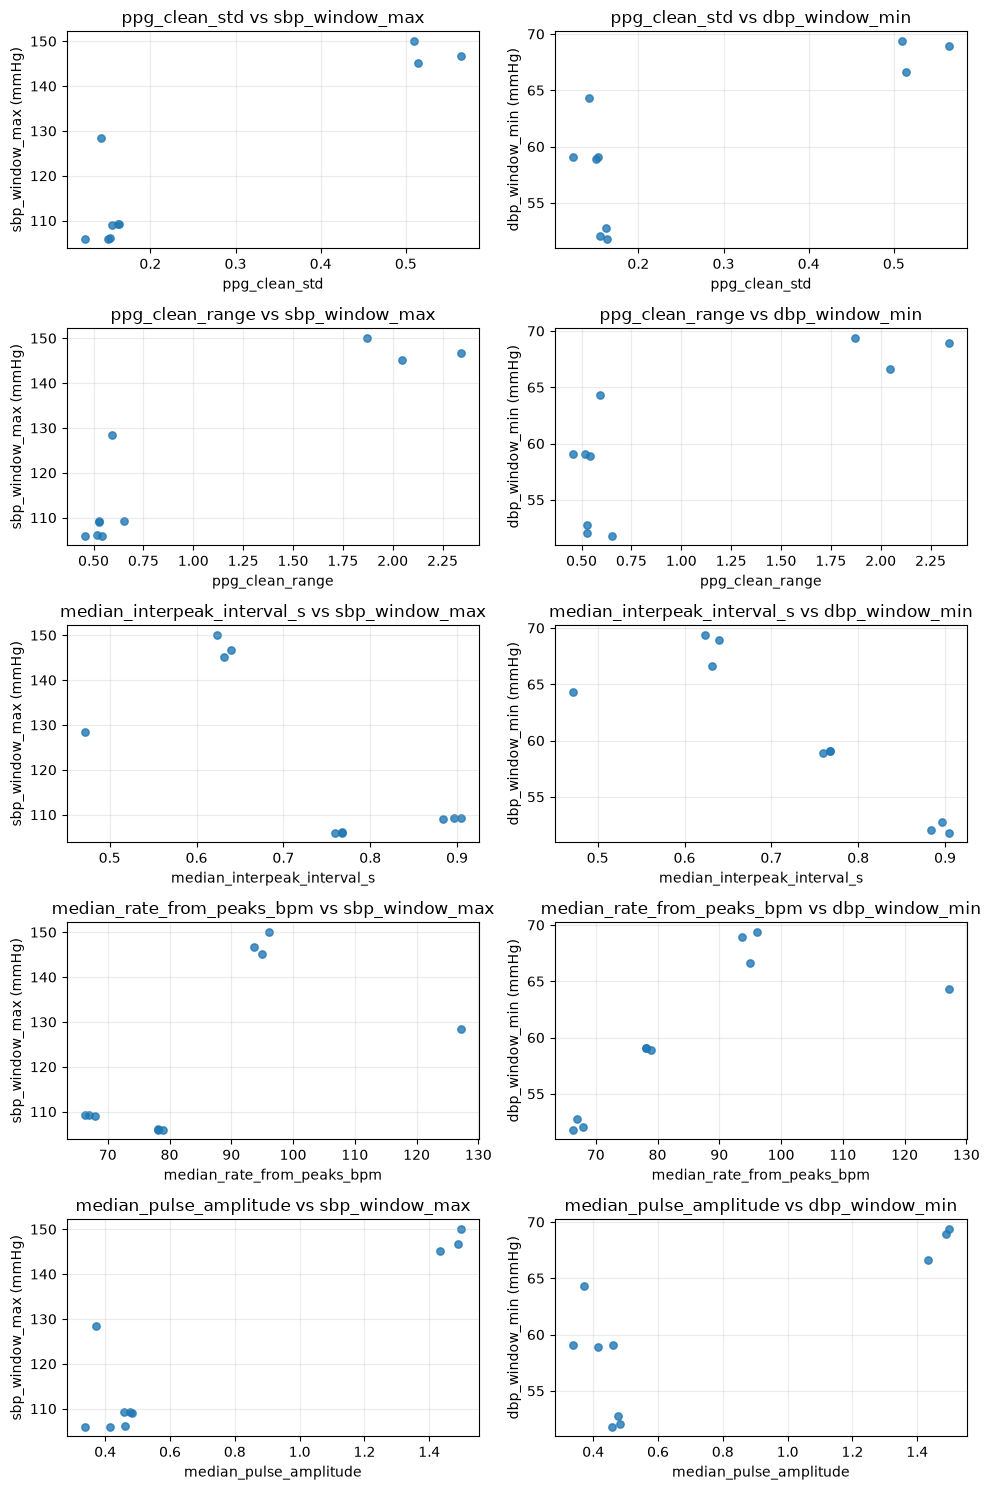

Correlation pairs use 10 successfully processed windows from 4 source records. Interpret as a pilot visualization only.


In [4]:
target_columns = ["sbp_window_max_target", "dbp_window_min_target"]
feature_columns = [
    column for column in features.columns
    if column.endswith("_feature")
]
valid_features = features.loc[features["processing_status"] == "ok"].copy()

correlation_rows = []
for feature_name in feature_columns:
    for target_name in target_columns:
        pair = valid_features[[feature_name, target_name]].dropna()
        if len(pair) < 2 or pair[feature_name].nunique() < 2 or pair[target_name].nunique() < 2:
            pearson_r = np.nan
            spearman_rho = np.nan
        else:
            pearson_r = pair[feature_name].corr(pair[target_name], method="pearson")
            spearman_rho = pair[feature_name].corr(pair[target_name], method="spearman")
        correlation_rows.append(
            {
                "feature": feature_name,
                "target": target_name,
                "n_windows": len(pair),
                "pearson_r": pearson_r,
                "spearman_rho": spearman_rho,
            }
        )

correlations = pd.DataFrame(correlation_rows)
display(correlations.sort_values(["target", "spearman_rho"], ascending=[True, False]))

plot_features = [
    "ppg_clean_std_feature",
    "ppg_clean_range_feature",
    "median_interpeak_interval_s_feature",
    "median_rate_from_peaks_bpm_feature",
    "median_pulse_amplitude_feature",
]
plot_features = [name for name in plot_features if name in valid_features.columns]
fig, axes = plt.subplots(
    len(plot_features), len(target_columns),
    figsize=(10, 3 * len(plot_features)),
    squeeze=False,
)

for row_index, feature_name in enumerate(plot_features):
    for column_index, target_name in enumerate(target_columns):
        pair = valid_features[[feature_name, target_name]].dropna()
        axes[row_index, column_index].scatter(
            pair[feature_name], pair[target_name], alpha=0.8, s=28
        )
        axes[row_index, column_index].set_xlabel(feature_name.replace("_feature", ""))
        axes[row_index, column_index].set_ylabel(target_name.replace("_target", " (mmHg)"))
        axes[row_index, column_index].set_title(f"{feature_name.replace('_feature', '')} vs {target_name.replace('_target', '')}")
        axes[row_index, column_index].grid(alpha=0.25)

fig.tight_layout()
plt.show()

print(
    f"Correlation pairs use {len(valid_features)} successfully processed windows "
    f"from {valid_features['record_index'].nunique()} source records. "
    "Interpret as a pilot visualization only."
)

## What these plots show

- The plots compare five NeuroKit-derived PPG features with the provisional ABP window-max SBP and window-min DBP labels. Each dot is one of 10 windows from only four source records.

- Larger cleaned PPG range, standard deviation, and pulse amplitude tend to occur with higher SBP. Shorter interpeak intervals tend to occur with higher DBP, which is consistent with the corresponding rate feature tending upward. Some Pearson and Spearman correlations differ, suggesting the relationships may not be consistently linear or monotonic in these few points.

- The scatterplots also show that windows from the same record cluster together. So the apparently strong correlations may be driven largely by differences between those four records, rather than a relationship that would hold for new records. The plots are useful for checking that the analysis runs and for generating hypotheses; they do not establish predictive value or causation. A broader sample and evaluation split by source record are needed before drawing conclusions.

## Recommended next steps for cleaning and processing

1. **Review detections before trusting features.** Check the overlays for representative normal-looking, one-zero, long-zero-run, low-range, and extreme-label windows. If this tiny random sample misses those categories, deliberately add known examples by their stored source coordinates.
2. **Keep raw signals immutable.** Store NeuroKit outputs and flags separately. Do not silently overwrite PPG, interpolate zeros, or remove windows. Compare raw and cleaned traces and document every transformation.
3. **Make quality flags explicit.** Retain zero count/fraction, longest consecutive zero run, detected peak count, NeuroKit quality summary, and processing status. A flag should trigger review; define any exclusion threshold only after inspecting examples and checking its effect on coverage.
4. **Treat PPG and ABP quality separately.** Poor PPG affects input/features; poor ABP affects the target. Review ABP peaks/troughs and compare whole-window extrema with beat-level summaries. The current max/min labels remain provisional.
5. **Process continuous records where practical.** Detect and clean on longer continuous segments, then map beats/features to 5-second windows. Isolated short windows can produce edge-related peak errors. Validate the mapping and preserve `part`, `record_index`, and `window_index`.
6. **Scale only after pilot validation.** Fix the NeuroKit2 version, parameters, feature definitions, and failure handling; then process all records reproducibly. Report success/failure counts and feature distributions.
7. **Prevent evaluation leakage.** Split by source record, not window, and keep exact duplicate records together. Do not assume each record is a verified unique patient. Fit any learned normalization or thresholds using training data only.

The current pilot features are candidates, not a final model schema. Compare them with a raw-window baseline and evaluate both SBP and DBP on a record-grouped holdout set.